## Importing the relevant libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import tensorflow as tf
import os, glob, random, shutil
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import array_to_img
from tensorflow.keras.layers import Conv2D, Conv2DTranspose, concatenate, MaxPool2D, Input, Dropout
from tensorflow.keras.models import Model, save_model
from tensorflow.keras.utils import plot_model

2025-04-17 02:36:16.348645: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1744857376.668461      31 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1744857376.753268      31 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


## Loading images and their respective masks

In [2]:
# Define your paths
images_path = '/kaggle/input/skin-cancer-lesions-segmentation/data/images'
masks_path = '/kaggle/input/skin-cancer-lesions-segmentation/data/masks'

# Get all image and mask files
image_files = sorted(glob.glob(os.path.join(images_path, '*.jpg')))
mask_files = sorted(glob.glob(os.path.join(masks_path, '*.png'))) 

# Match by filename
image_basename_to_path = {os.path.basename(f): f for f in image_files}
mask_basename_to_path = {os.path.basename(f): f for f in mask_files}

# Strip extensions for matching
image_keys = {os.path.splitext(f)[0] for f in image_basename_to_path.keys()}
mask_keys = {os.path.splitext(f)[0] for f in mask_basename_to_path.keys()}

# Only keep pairs that exist in both directories
common_keys = image_keys & mask_keys

# Recreate matched image and mask pairs with valid extensions
image_paths = [image_basename_to_path[f"{k}.jpg"] for k in common_keys]
mask_paths = [mask_basename_to_path[f"{k}.png"] for k in common_keys]

In [3]:
# Sort for reproducibility
image_paths.sort()
mask_paths.sort()

In [4]:
train_images, test_images, train_masks, test_masks = train_test_split(
    image_paths, mask_paths, test_size=0.2, random_state=42
)

train_images, val_images, train_masks, val_masks = train_test_split(
    train_images, train_masks, test_size=0.1, random_state=42 
)

print(f"Train: {len(train_images)}")
print(f"Val: {len(val_images)}")
print(f"Test: {len(test_images)}")

Train: 7210
Val: 802
Test: 2003


## Preprocessing image-mask pairs and performing train-test-val split

In [5]:
def load_image_mask_pairs(image_paths, mask_paths):
    images = tf.io.read_file(image_paths)
    images = tf.image.decode_jpeg(images, channels=3)
    images = tf.image.resize(images, [64,64])
    images = tf.cast(images,tf.float32) / 255.

    masks = tf.io.read_file(mask_paths)
    masks = tf.image.decode_png(masks, channels=1)
    masks = tf.image.resize(masks, [64,64])
    masks = tf.cast(masks > 127, tf.float32)
    return images, masks

In [6]:
def get_dataset(image_paths, mask_paths, batch_size=32):
    dataset = tf.data.Dataset.from_tensor_slices((image_paths, mask_paths))
    dataset = dataset.map(load_image_mask_pairs, num_parallel_calls = tf.data.AUTOTUNE)
    dataset = dataset.shuffle(100).batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return dataset

In [7]:
train_dataset = get_dataset(train_images, train_masks)
test_dataset = get_dataset(test_images, test_masks)
val_dataset = get_dataset(val_images, val_masks)

I0000 00:00:1744857392.328682      31 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1744857392.329476      31 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


## Visualizing a sample of train dataset

In [8]:
def display_sample(images):
    plt.figure(figsize=(10,10))
    titles = ['Input Image','True Mask','Predicted Mask']

    for i in range(len(images)):
        plt.subplot(1,len(images),i+1)
        plt.title(titles[i])
        plt.imshow(array_to_img(images[i]))
        plt.axis('off')

    plt.show()

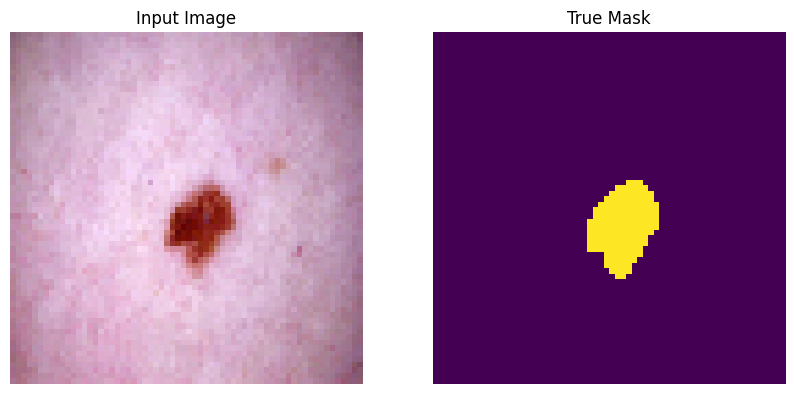

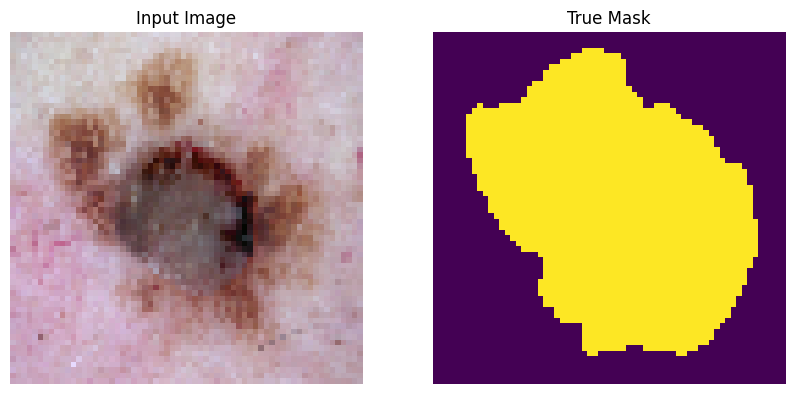

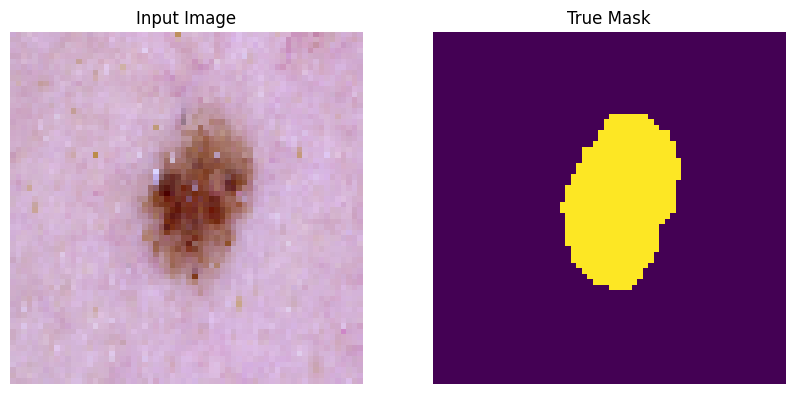

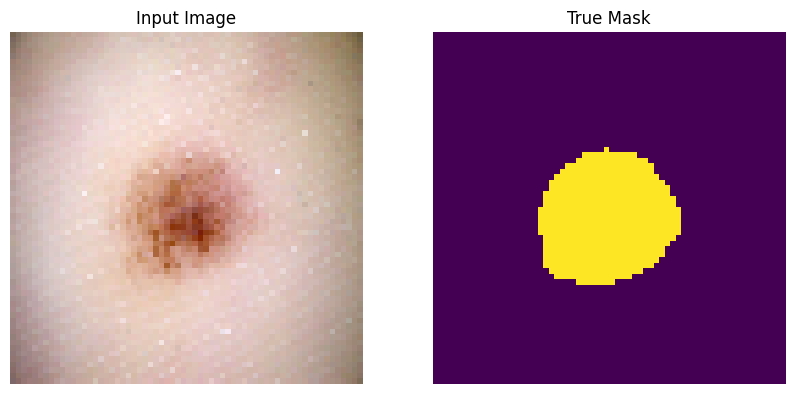

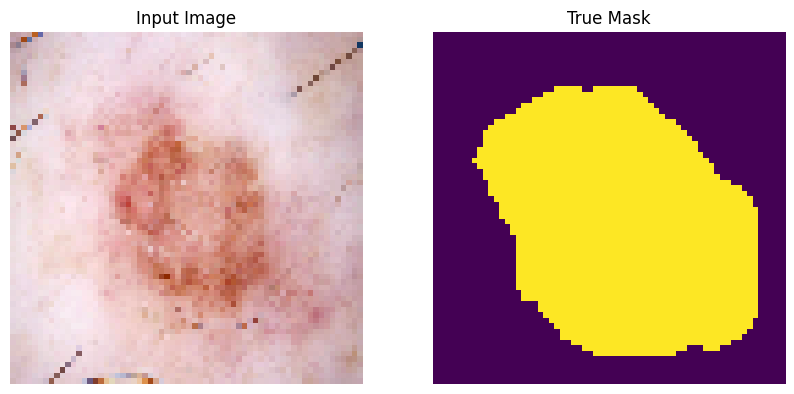

In [9]:
for images, masks in train_dataset.take(5):
    sample_image, sample_mask = images[0], masks[0]
    display_sample([sample_image, sample_mask])

In [10]:
sample_image.shape

TensorShape([64, 64, 3])

## Defining the U-Net model architecture

In [11]:
def double_conv_block(x, n_filters):
    x = Conv2D(n_filters=n_filters, kernel_size=(3,3), activation='relu', padding='same', kernel_initializer='he_normal')(x)
    x = Conv2D(n_filters=n_filters, kernel_size=(3,3), activation='relu', padding='same', kernel_initializer='he_normal')(x)
    return x

In [12]:
def downsample_block(x, n_filters):
    fwd_block = double_conv_block(x=x, n_filters=n_filters)
    x = MaxPool2D((2,2))(fwd_block)
    x = Dropout(0.3)(x)
    return fwd_block, x

In [13]:
def upsample_block(x, conv_features, n_filters):
    x = Conv2DTranspose(filters=n_filters,kernel_size=(3,3),strides=2,padding='same')(x)
    x = concatenate([x,conv_features])
    x = Dropout(0.25)(x)
    x = double_conv_block(x,n_filters)
    return x

In [14]:
def build_unet_model(output_channels):
    # input layer
    inputs = Input(shape=(64,64,3))

    # encoder block - compress images - contracting path - downsampling
    f1, p1 = downsample_block(inputs,64)
    f2, p2 = downsample_block(p1,128)
    f3, p3 = downsample_block(p2,256)
    f4, p4 = downsample_block(p3,512)

    # intermediate block - bridge - contains higher level features - highly compressed
    intermediate_block = double_conv_block(p4,1024)

    # decoder block - upsampling - concatenates encoder features for precise localization
    u6 = upsample_block(intermediate_block,f4,512)
    u7 = upsample_block(u6,f3,256)
    u8 = upsample_block(u7,f2,128)
    u9 = upsample_block(u8,f1,64)

    outputs = Conv2D(output_channels,1,activation='softmax',padding='same')(u9)
    unet_model = Model(inputs,outputs,name='U-Net')
    return unet_model

In [15]:
output_channels = 3
unet_model = build_unet_model(output_channels)
unet_model.summary()

Model: "U-Net"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 64, 64, 3)      │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d (Conv2D)           │ (None, 64, 64, 64)     │          1,792 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_1 (Conv2D)         │ (None, 64, 64, 64)     │         36,928 │ conv2d[0][0]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d             │ (None, 32, 32, 64)     │              0 │ conv2d_1[0][0]         │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout (Dropout)         │ (None, 32, 32, 64)     │              0 │ max_pooling2d[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_2 (Conv2D)         │ (None, 32, 32, 128)    │         73,856 │ dropout[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_3 (Conv2D)         │ (None, 32, 32, 128)    │        147,584 │ conv2d_2[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_1           │ (None, 16, 16, 128)    │              0 │ conv2d_3[0][0]         │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_1 (Dropout)       │ (None, 16, 16, 128)    │              0 │ max_pooling2d_1[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_4 (Conv2D)         │ (None, 16, 16, 256)    │        295,168 │ dropout_1[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_5 (Conv2D)         │ (None, 16, 16, 256)    │        590,080 │ conv2d_4[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_2           │ (None, 8, 8, 256)      │              0 │ conv2d_5[0][0]         │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_2 (Dropout)       │ (None, 8, 8, 256)      │              0 │ max_pooling2d_2[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_6 (Conv2D)         │ (None, 8, 8, 512)      │      1,180,160 │ dropout_2[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_7 (Conv2D)         │ (None, 8, 8, 512)      │      2,359,808 │ conv2d_6[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_3           │ (None, 4, 4, 512)      │              0 │ conv2d_7[0][0]         │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_3 (Dropout)       │ (None, 4, 4, 512)      │              0 │ max_pooling2d_3[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_8 (Conv2D)    

 Total params: 34,513,475 (131.66 MB)

 Trainable params: 34,513,475 (131.66 MB)

 Non-trainable params: 0 (0.00 B)

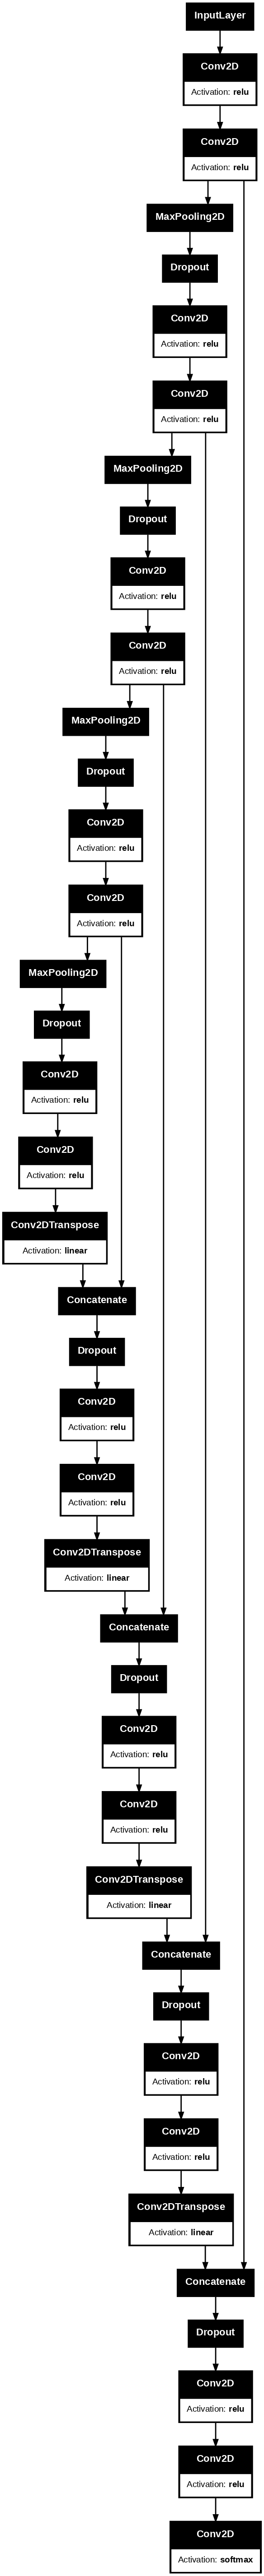

In [16]:
plot_model(unet_model,'unet_model.png', dpi=100, show_layer_activations=True)

## Training U-Net Model

In [17]:
unet_model.compile(loss='sparse_categorical_crossentropy',optimizer='adam',metrics=['accuracy'])

In [18]:
epochs = 20
batch_size = 64

steps_per_epoch = len(train_images) // batch_size
validation_steps = len(test_images) // batch_size

history = unet_model.fit(train_dataset,
                        epochs=epochs,
                        steps_per_epoch=steps_per_epoch,
                        validation_steps=validation_steps,
                        validation_data=test_dataset)

Epoch 1/20


I0000 00:00:1744857406.453582      96 service.cc:148] XLA service 0x7af3e801a110 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1744857406.455038      96 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1744857406.455058      96 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
W0000 00:00:1744857407.078943      96 assert_op.cc:38] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
I0000 00:00:1744857407.467710      96 cuda_dnn.cc:529] Loaded cuDNN version 90300
2025-04-17 02:36:52.668772: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Trying algorithm eng50{} for conv (f32[32,512,9,9]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,1024,4,4]{3,2,1,0}, f32[1024,512,3,3]{3,2,1,0}), window={size=3x3 stride=2x2}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBackwardI

112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - accuracy: 0.7899 - loss: 0.5156

W0000 00:00:1744857447.155578      94 assert_op.cc:38] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert


112/112 ━━━━━━━━━━━━━━━━━━━━ 59s 230ms/step - accuracy: 0.7902 - loss: 0.5148 - val_accuracy: 0.8148 - val_loss: 0.3907
Epoch 2/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 20s 176ms/step - accuracy: 0.8462 - loss: 0.3512 - val_accuracy: 0.8790 - val_loss: 0.2955
Epoch 3/20
  1/112 ━━━━━━━━━━━━━━━━━━━━ 15s 141ms/step - accuracy: 0.8633 - loss: 0.3076

W0000 00:00:1744857475.885650      93 assert_op.cc:38] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert


  2/112 ━━━━━━━━━━━━━━━━━━━━ 32:38 18s/step - accuracy: 0.8664 - loss: 0.3067

/usr/lib/python3.11/contextlib.py:158: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)
W0000 00:00:1744857493.436750      93 assert_op.cc:38] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert


112/112 ━━━━━━━━━━━━━━━━━━━━ 23s 202ms/step - accuracy: 0.8694 - loss: 0.3059 - val_accuracy: 0.8746 - val_loss: 0.3167
Epoch 4/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 20s 177ms/step - accuracy: 0.8879 - loss: 0.2860 - val_accuracy: 0.9231 - val_loss: 0.2217
Epoch 5/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 19s 172ms/step - accuracy: 0.9270 - loss: 0.1990 - val_accuracy: 0.9312 - val_loss: 0.1815
Epoch 6/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9119 - loss: 0.2025 - val_accuracy: 0.9521 - val_loss: 0.1188
Epoch 7/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 21s 181ms/step - accuracy: 0.9272 - loss: 0.1922 - val_accuracy: 0.9419 - val_loss: 0.1482
Epoch 8/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 20s 181ms/step - accuracy: 0.9391 - loss: 0.1580 - val_accuracy: 0.9439 - val_loss: 0.1424
Epoch 9/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9364 - loss: 0.1528 - val_accuracy: 0.9599 - val_loss: 0.1119
Epoch 10/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 21s 184ms/step - accuracy: 0.9451 - loss: 0.1393 - val_accu

## Visualizing model performance

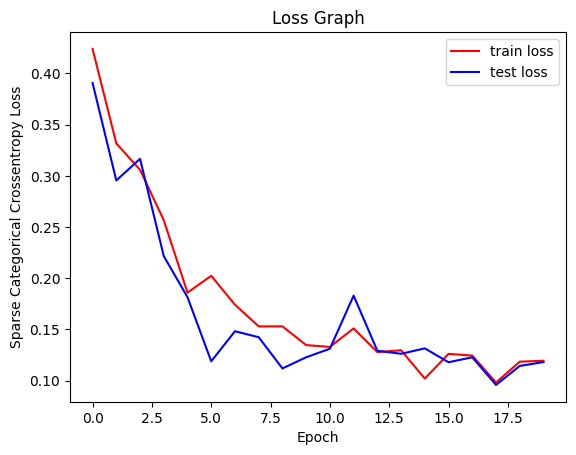

In [20]:
plt.plot(history.history['loss'],'r',label='train loss')
plt.plot(history.history['val_loss'],'b',label='test loss')
plt.xlabel('Epoch')
plt.ylabel('Sparse Categorical Crossentropy Loss')
plt.title('Loss Graph')
plt.legend()
plt.show();

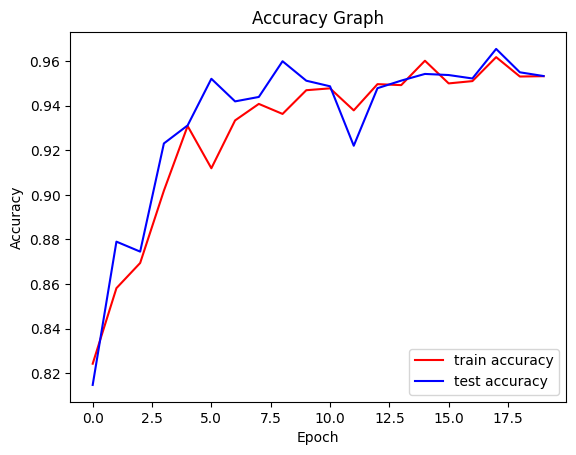

In [21]:
plt.plot(history.history['accuracy'],'r',label='train accuracy')
plt.plot(history.history['val_accuracy'],'b',label='test accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy Graph')
plt.legend()
plt.show();

## Making test predictions

In [24]:
def create_prediction_mask(prediction_mask, batch_idx):
    prediction_mask = tf.argmax(prediction_mask, axis=-1)
    prediction_mask = prediction_mask[..., tf.newaxis]
    return prediction_mask[batch_idx]

In [25]:
def segment_image(dataset=None,num=1):
    if dataset:
        for images, masks in dataset.take(num):
            prediction_masks = unet_model.predict(images)
            display_sample([images[0], masks[0], create_prediction_mask(prediction_masks,0)])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


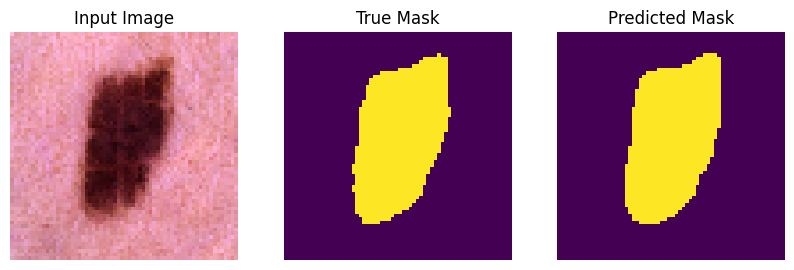

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


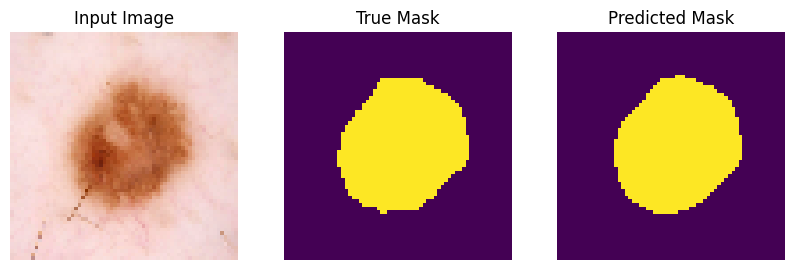

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


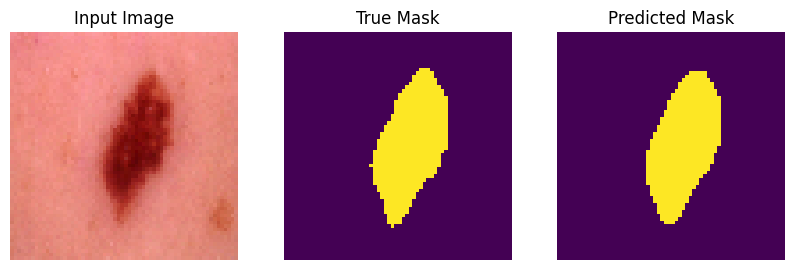

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


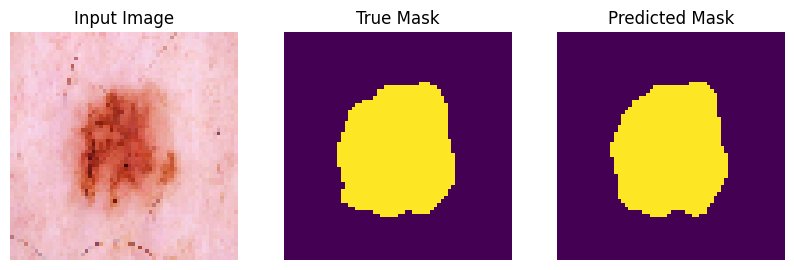

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


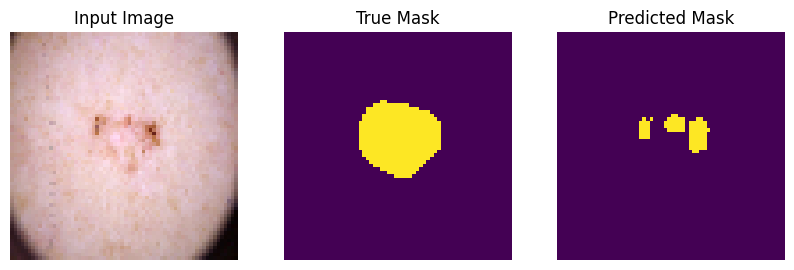

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


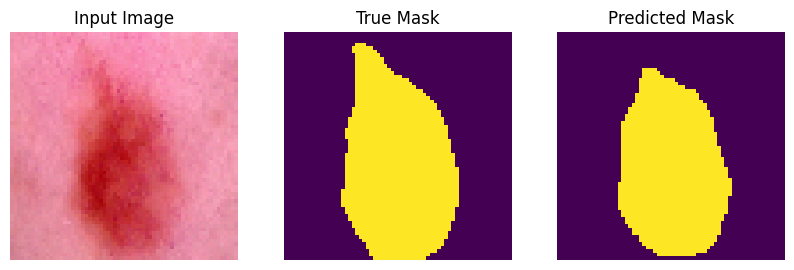

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


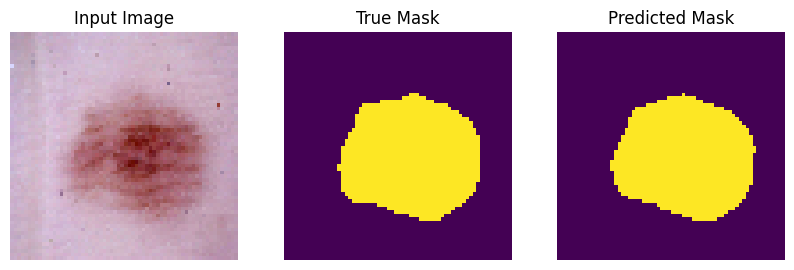

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


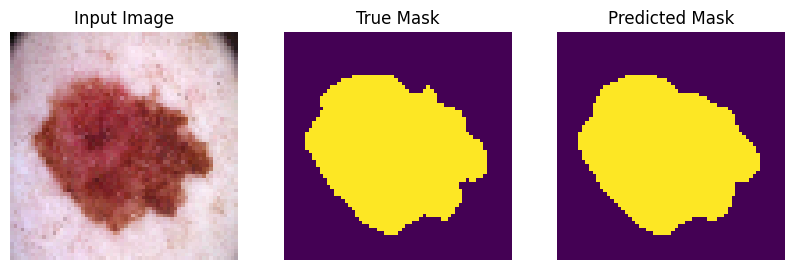

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


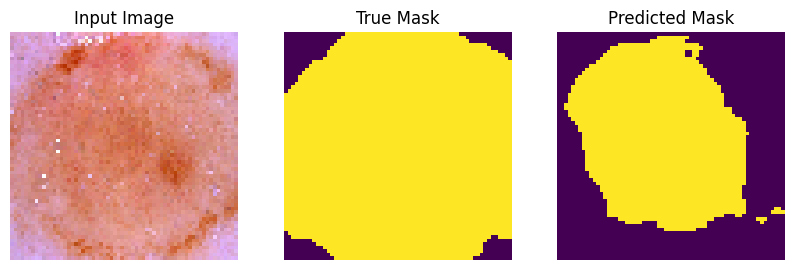

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


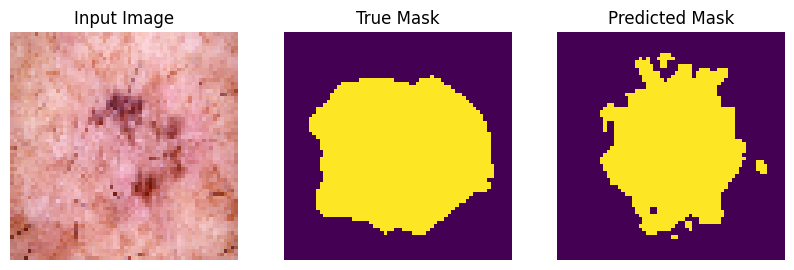

In [26]:
segment_image(dataset=val_dataset,num=10)

## Save the model

In [27]:
unet_model.save('skin_cancer_lesions_segmentation_unet_model.keras')